In [2]:
"""
Quick sanity check on the two updated files, independently (no merge).

Prints:
  - BAT file: total rows, and how many posts are flagged (=YES/1) for
    EX, EMO, COG, MD
  - Exit file: total rows, and counts for each exit_intention_class
    (no_exit / exit_contemplating / exit_explicit)

Run locally:
    python3 check_file_totals.py
"""

import pandas as pd

BASE_DIR = "/Users/nadia/Desktop/redditRun_june/"
BAT_FILE = BASE_DIR + "BAT_slurm/bat_posts_results_final_patched.csv"
EXIT_FILE = BASE_DIR + "EXIT_slurm/exit_annotated_pass1_merged.csv"

# ---------------------------------------------------------------
# BAT file
# ---------------------------------------------------------------
print("=" * 60)
print("BAT FILE:", BAT_FILE)
print("=" * 60)

bat = pd.read_csv(BAT_FILE)
print(f"Total rows: {len(bat):,}")

constructs = [c for c in ["EX", "EMO", "COG", "MD"] if c in bat.columns]
print(f"Construct columns found: {constructs}\n")

for c in constructs:
    raw_vals = bat[c].astype(str).str.strip().str.upper()
    print(f"{c} raw value counts:")
    print(raw_vals.value_counts().to_string())
    n_flagged = (raw_vals == "YES").sum()
    print(f"  -> {c} flagged (YES): {n_flagged:,} ({n_flagged / len(bat) * 100:.2f}%)\n")

if "bat_score" in bat.columns:
    print("bat_score distribution (0-4, count of constructs flagged per post):")
    print(bat["bat_score"].value_counts().sort_index().to_string())

# ---------------------------------------------------------------
# Exit file
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("EXIT FILE:", EXIT_FILE)
print("=" * 60)

exit_df = pd.read_csv(EXIT_FILE)
print(f"Total rows: {len(exit_df):,}")

exit_col_candidates = [c for c in exit_df.columns if "exit" in c.lower() and "class" in c.lower()]
if not exit_col_candidates:
    exit_col_candidates = [c for c in exit_df.columns if "exit" in c.lower()]
exit_col = exit_col_candidates[0]
print(f"Using exit column: '{exit_col}'\n")

exit_counts = exit_df[exit_col].value_counts()
print("Exit intention class counts:")
print(exit_counts.to_string())
print()
for cls, count in exit_counts.items():
    print(f"  {cls}: {count:,} ({count / len(exit_df) * 100:.2f}%)")

print("\nDone.")

BAT FILE: /Users/nadia/Desktop/redditRun_june/BAT_slurm/bat_posts_results_final_patched.csv
Total rows: 144,652
Construct columns found: ['EX', 'EMO', 'COG', 'MD']

EX raw value counts:
EX
NO     138478
YES      6174
  -> EX flagged (YES): 6,174 (4.27%)

EMO raw value counts:
EMO
NO     136980
YES      7672
  -> EMO flagged (YES): 7,672 (5.30%)

COG raw value counts:
COG
NO     142299
YES      2353
  -> COG flagged (YES): 2,353 (1.63%)

MD raw value counts:
MD
NO     141258
YES      3394
  -> MD flagged (YES): 3,394 (2.35%)

bat_score distribution (0-4, count of constructs flagged per post):
bat_score
0    132415
1      7232
2      3043
3      1573
4       389

EXIT FILE: /Users/nadia/Desktop/redditRun_june/EXIT_slurm/exit_annotated_pass1_merged.csv
Total rows: 144,652
Using exit column: 'exit_intention_class'

Exit intention class counts:
exit_intention_class
no_exit               137779
exit_contemplating      5354
exit_explicit           1519

  no_exit: 137,779 (95.25%)
  exit_cont

Loading files...

bat_posts_results_with_dates.csv: 144,652 rows
columns: ['row_type', 'post_id', 'comment_id', 'text', 'triage', 'na_subtype', 'triage_reason', 'EX', 'EMO', 'COG', 'MD', 'bat_score', 'EX_reasoning', 'EMO_reasoning', 'COG_reasoning', 'MD_reasoning']

exit_annotated_pass1.csv: 144,652 rows
columns: ['row_type', 'post_id', 'comment_id', 'text', 'triage', 'na_subtype', 'triage_reason', 'EX', 'EMO', 'COG', 'MD', 'bat_score', 'EX_reasoning', 'EMO_reasoning', 'COG_reasoning', 'MD_reasoning', 'exit_intention_class', 'exit_confidence', 'exit_evidence_span', 'exit_reasoning', 'exit_level', 'exit_reason_primary', 'exit_reason_secondary']

Merging bat['post_id'] <-> exit['post_id']
Using exit column: 'exit_intention_class' (values: ['no_exit', 'exit_contemplating', 'exit_explicit'])

Merged: 144,652 rows (bat=144,652, exit=144,652)

Construct columns found: ['EX', 'EMO', 'COG', 'MD']
Sample raw values in 'EX': ['NO', 'YES']
After conversion, value counts for 'EX':
EX
0    138478
1

/var/folders/41/b55bchyx62j34hmsgfhfk2gw0000gp/T/ipykernel_37554/259844463.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_table = df.groupby(exit_col)[constructs].sum().astype(int)
/var/folders/41/b55bchyx62j34hmsgfhfk2gw0000gp/T/ipykernel_37554/259844463.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = df.groupby(exit_col).size()
/var/folders/41/b55bchyx62j34hmsgfhfk2gw0000gp/T/ipykernel_37554/259844463.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse


Saved chart to /Users/nadia/Desktop/redditRun_june/construct_exit_analysis/construct_by_exit_class_grouped_bar.png

CONSTRUCT-LEVEL ASSOCIATION WITH EXIT INTENTION

EX:
exit_intention_class  no_exit  exit_contemplating  exit_explicit
EX                                                              
0                      133511                3880           1087
1                        4268                1474            432
  chi2=9724.85, p=0.00e+00, Cramér's V=0.2593
  exit rate when EX=1: 30.87%  |  when EX=0: 3.59%  (diff: +27.28pp)

EMO:
exit_intention_class  no_exit  exit_contemplating  exit_explicit
EMO                                                             
0                      132043                3869           1068
1                        5736                1485            451
  chi2=7519.89, p=0.00e+00, Cramér's V=0.2280
  exit rate when EMO=1: 25.23%  |  when EMO=0: 3.60%  (diff: +21.63pp)

COG:
exit_intention_class  no_exit  exit_contemplating  exit_explicit
C

/var/folders/41/b55bchyx62j34hmsgfhfk2gw0000gp/T/ipykernel_37554/259844463.py:205: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_class = df.groupby(exit_col)["bat_score"].agg(["mean", "median", "count"])



Saved chart to /Users/nadia/Desktop/redditRun_june/construct_exit_analysis/construct_exit_rate_diff.png

Done. Outputs saved in: /Users/nadia/Desktop/redditRun_june/construct_exit_analysis/


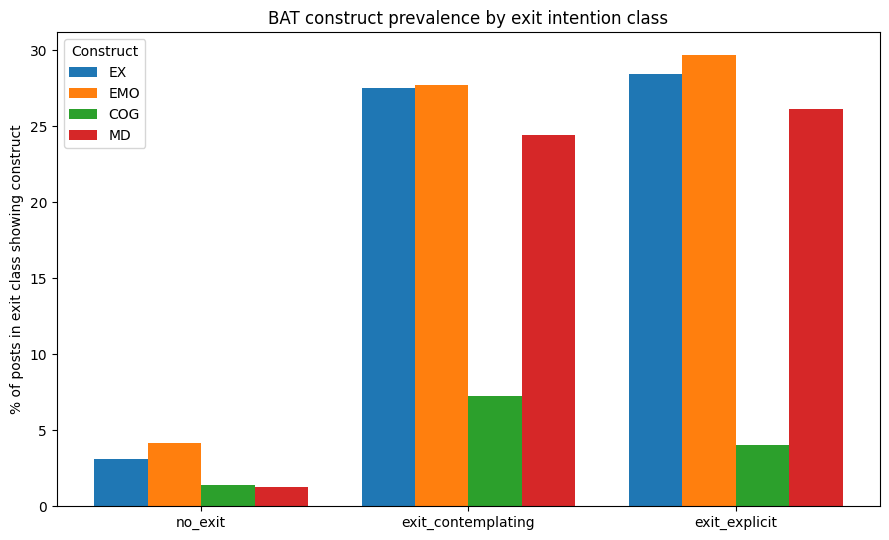

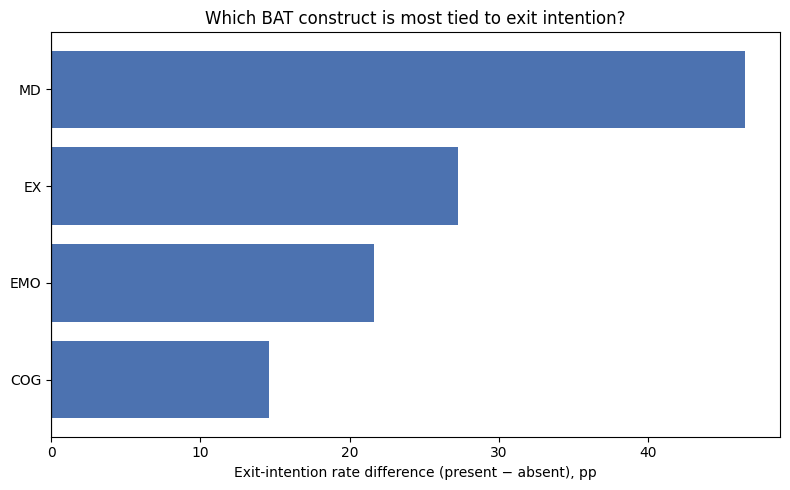

In [3]:
"""
Correlate BAT constructs (EX, EMO, COG, MD) and bat_score with exit_intention_class.

Run locally:
    python3 construct_exit_correlation.py

Edit BASE_DIR below if your files live somewhere else.
july 23- updating here the output directory
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

BASE_DIR = "/Users/nadia/Desktop/redditRun_june/"
BAT_FILE = BASE_DIR + "BAT_slurm/bat_posts_results_final_patched.csv"
EXIT_FILE = BASE_DIR + "EXIT_slurm/exit_annotated_pass1_merged.csv"
OUT_DIR = BASE_DIR + "construct_exit_analysis/"

import os
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------------------
# 1. Load
# ---------------------------------------------------------------
print("Loading files...")
bat = pd.read_csv(BAT_FILE)
exit_df = pd.read_csv(EXIT_FILE)

print(f"\nbat_posts_results_with_dates.csv: {bat.shape[0]:,} rows")
print(f"columns: {list(bat.columns)}")
print(f"\nexit_annotated_pass1.csv: {exit_df.shape[0]:,} rows")
print(f"columns: {list(exit_df.columns)}")

# ---------------------------------------------------------------
# 2. Figure out merge key + exit column automatically
# ---------------------------------------------------------------
# exit_annotated_pass1.csv uses a single 'id' column instead of separate
# post_id/comment_id. Build a matching key on the bat side: use comment_id
# when present (it's a comment row), else post_id (it's a post row).
if "id" in exit_df.columns and "post_id" in bat.columns and "comment_id" in bat.columns:
    bat["merge_id"] = bat["comment_id"].where(bat["comment_id"].notna(), bat["post_id"])
    key = "merge_id"
    exit_key = "id"
else:
    key_candidates = [c for c in ["post_id", "comment_id"] if c in bat.columns and c in exit_df.columns]
    if not key_candidates:
        raise ValueError(
            "Couldn't find shared key columns. "
            f"bat columns: {list(bat.columns)} | exit columns: {list(exit_df.columns)}"
        )
    key = exit_key = key_candidates[0]

print(f"\nMerging bat['{key}'] <-> exit['{exit_key}']")

exit_col_candidates = [c for c in exit_df.columns if "exit" in c.lower() and "class" in c.lower()]
if not exit_col_candidates:
    exit_col_candidates = [c for c in exit_df.columns if "exit" in c.lower()]
if not exit_col_candidates:
    raise ValueError(f"Couldn't find an exit-intention column. exit columns: {list(exit_df.columns)}")
exit_col = exit_col_candidates[0]
print(f"Using exit column: '{exit_col}' (values: {exit_df[exit_col].unique().tolist()})")

# ---------------------------------------------------------------
# 3. Merge
# ---------------------------------------------------------------
df = bat.merge(
    exit_df[[exit_key, exit_col]],
    left_on=key, right_on=exit_key, how="inner"
)
print(f"\nMerged: {df.shape[0]:,} rows (bat={bat.shape[0]:,}, exit={exit_df.shape[0]:,})")
if df.shape[0] < 0.95 * min(bat.shape[0], exit_df.shape[0]):
    print("WARNING: merge matched fewer rows than expected — check that the id schemes actually line up "
          "(e.g. try matching on created_utc + text instead).")

# Order exit classes sensibly if they match expected labels
expected_order = ["no_exit", "exit_contemplating", "exit_explicit"]
present = [c for c in expected_order if c in df[exit_col].unique()]
exit_order = present if len(present) == df[exit_col].nunique() else sorted(df[exit_col].dropna().unique())
df[exit_col] = pd.Categorical(df[exit_col], categories=exit_order, ordered=True)

constructs = [c for c in ["EX", "EMO", "COG", "MD"] if c in df.columns]
print(f"\nConstruct columns found: {constructs}")
print(f"Sample raw values in '{constructs[0]}': {df[constructs[0]].unique().tolist()[:5]}")

# The construct columns come in as YES/NO strings (or similar) rather than 0/1 —
# normalize to binary integers so sum()/mean() work correctly.
for c in constructs:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.strip().str.upper().map({"YES": 1, "NO": 0, "1": 1, "0": 0, "TRUE": 1, "FALSE": 0})
    df[c] = df[c].fillna(0).astype(int)
print(f"After conversion, value counts for '{constructs[0]}':\n{df[constructs[0]].value_counts()}")

# ---------------------------------------------------------------
# 4. MAIN ANSWER: how many posts in each exit class show each construct?
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("COUNTS: construct presence (=1) by exit intention class")
print("=" * 70)

counts_table = df.groupby(exit_col)[constructs].sum().astype(int)
totals = df.groupby(exit_col).size()
counts_table["total_posts_in_class"] = totals

print("\nRaw counts (how many posts in each class have that construct flagged):")
print(counts_table.to_string())

pct_table = df.groupby(exit_col)[constructs].mean() * 100
pct_table = pct_table.round(2)
print("\nPercent of each exit class showing each construct:")
print(pct_table.to_string())

counts_table.to_csv(OUT_DIR + "construct_counts_by_exit_class.csv")
pct_table.to_csv(OUT_DIR + "construct_pct_by_exit_class.csv")

# Also: within each construct, how the flagged posts split across exit classes
print("\n" + "=" * 70)
print("REVERSE VIEW: of posts with each construct flagged, how do they split across exit classes?")
print("=" * 70)
for construct in constructs:
    sub = df[df[construct] == 1]
    dist = sub[exit_col].value_counts().reindex(exit_order).fillna(0).astype(int)
    dist_pct = (dist / dist.sum() * 100).round(2)
    print(f"\n{construct} (n={len(sub):,} posts flagged):")
    for cls in exit_order:
        print(f"  {cls}: {dist[cls]:,} ({dist_pct[cls]}%)")

# Grouped bar chart: exit class on x-axis, one bar per construct
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(exit_order))
width = 0.2
for i, construct in enumerate(constructs):
    vals = pct_table.loc[exit_order, construct].values
    ax.bar(x + i * width, vals, width, label=construct)
ax.set_xticks(x + width * (len(constructs) - 1) / 2)
ax.set_xticklabels(exit_order)
ax.set_ylabel("% of posts in exit class showing construct")
ax.set_title("BAT construct prevalence by exit intention class")
ax.legend(title="Construct")
plt.tight_layout()
plt.savefig(OUT_DIR + "construct_by_exit_class_grouped_bar.png", dpi=150)
print(f"\nSaved chart to {OUT_DIR}construct_by_exit_class_grouped_bar.png")

# ---------------------------------------------------------------
# 5. (Optional deeper stats) Per-construct association with exit intention
# ---------------------------------------------------------------
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

results = []
print("\n" + "=" * 70)
print("CONSTRUCT-LEVEL ASSOCIATION WITH EXIT INTENTION")
print("=" * 70)

for construct in constructs:
    ct = pd.crosstab(df[construct], df[exit_col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(ct)

    # exit rate (contemplating+explicit) when construct present vs absent
    exit_flag = df[exit_col].isin(["exit_contemplating", "exit_explicit"]) if "exit_contemplating" in exit_order else None
    if exit_flag is not None:
        rate_present = exit_flag[df[construct] == 1].mean() * 100
        rate_absent = exit_flag[df[construct] == 0].mean() * 100
    else:
        rate_present = rate_absent = np.nan

    results.append({
        "construct": construct,
        "n_present": int((df[construct] == 1).sum()),
        "chi2": round(chi2, 2),
        "p_value": p,
        "cramers_v": round(v, 4),
        "exit_rate_when_present_%": round(rate_present, 2),
        "exit_rate_when_absent_%": round(rate_absent, 2),
        "exit_rate_diff_pp": round(rate_present - rate_absent, 2),
    })

    print(f"\n{construct}:")
    print(ct)
    print(f"  chi2={chi2:.2f}, p={p:.2e}, Cramér's V={v:.4f}")
    if exit_flag is not None:
        print(f"  exit rate when {construct}=1: {rate_present:.2f}%  |  when {construct}=0: {rate_absent:.2f}%  (diff: {rate_present - rate_absent:+.2f}pp)")

results_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
print("\n" + "=" * 70)
print("SUMMARY (ranked by strength of association)")
print("=" * 70)
print(results_df.to_string(index=False))
results_df.to_csv(OUT_DIR + "construct_exit_association_summary.csv", index=False)

# ---------------------------------------------------------------
# 5. bat_score (ordinal 0-4) vs exit intention (ordinal)
# ---------------------------------------------------------------
if "bat_score" in df.columns:
    exit_numeric = df[exit_col].cat.codes  # 0,1,2 in exit_order
    valid = exit_numeric >= 0
    rho, p_rho = stats.spearmanr(df.loc[valid, "bat_score"], exit_numeric[valid])
    print(f"\nbat_score vs exit_intention (Spearman rho): {rho:.4f}, p={p_rho:.2e}")

    mean_by_class = df.groupby(exit_col)["bat_score"].agg(["mean", "median", "count"])
    print("\nMean bat_score by exit class:")
    print(mean_by_class)
    mean_by_class.to_csv(OUT_DIR + "bat_score_by_exit_class.csv")

# ---------------------------------------------------------------
# 6. Chart: exit rate by construct
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = results_df.sort_values("exit_rate_diff_pp")
ax.barh(plot_df["construct"], plot_df["exit_rate_diff_pp"], color="#4C72B0")
ax.set_xlabel("Exit-intention rate difference (present − absent), pp")
ax.set_title("Which BAT construct is most tied to exit intention?")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(OUT_DIR + "construct_exit_rate_diff.png", dpi=150)
print(f"\nSaved chart to {OUT_DIR}construct_exit_rate_diff.png")

print("\nDone. Outputs saved in:", OUT_DIR)

In [4]:
# july 23 -> updating here 
"""
Standalone: counts of BAT constructs (EX, EMO, COG, MD) by exit intention class,
and the reverse view (of posts flagged with each construct, how do they split
across exit classes).

Run locally:
    python3 construct_exit_counts.py

Edit BASE_DIR below if your files live somewhere else.
"""

import pandas as pd
import os

BASE_DIR = "/Users/nadia/Desktop/redditRun_june/"
BAT_FILE = BASE_DIR + "BAT_slurm/bat_posts_results_final_patched.csv"
EXIT_FILE = BASE_DIR + "EXIT_slurm/exit_annotated_pass1_merged.csv"
OUT_DIR = BASE_DIR + "construct_exit_analysis1/"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------------------------------------------
# 1. Load
# ---------------------------------------------------------------
print("Loading files...")
bat = pd.read_csv(BAT_FILE)
exit_df = pd.read_csv(EXIT_FILE)
print(f"bat: {bat.shape[0]:,} rows | exit: {exit_df.shape[0]:,} rows")

# ---------------------------------------------------------------
# 2. Merge (bat's post_id/comment_id -> exit's id column, auto-detected
#    in case the new files use different column names)
# ---------------------------------------------------------------
print(f"\nbat columns: {list(bat.columns)}")
print(f"exit columns: {list(exit_df.columns)}")

if "post_id" in bat.columns and "comment_id" in bat.columns:
    bat["merge_id"] = bat["comment_id"].where(bat["comment_id"].notna(), bat["post_id"])
    bat_key = "merge_id"
elif "post_id" in bat.columns:
    bat_key = "post_id"
else:
    raise ValueError(f"Couldn't find post_id/comment_id in bat file. Columns: {list(bat.columns)}")

exit_key_candidates = [c for c in ["id", "post_id"] if c in exit_df.columns]
if not exit_key_candidates:
    raise ValueError(f"Couldn't find an id column in exit file. Columns: {list(exit_df.columns)}")
exit_key = exit_key_candidates[0]

exit_col_candidates = [c for c in exit_df.columns if "exit" in c.lower() and "class" in c.lower()]
if not exit_col_candidates:
    exit_col_candidates = [c for c in exit_df.columns if "exit" in c.lower() and "intention" in c.lower()]
exit_col = exit_col_candidates[0] if exit_col_candidates else "exit_intention_class"
print(f"Merging bat['{bat_key}'] <-> exit['{exit_key}'], using exit column '{exit_col}'")

df = bat.merge(
    exit_df[[exit_key, exit_col]],
    left_on=bat_key, right_on=exit_key, how="inner"
)
print(f"Merged: {df.shape[0]:,} rows")
if df.shape[0] < 0.95 * min(len(bat), len(exit_df)):
    print("WARNING: merge matched fewer rows than expected — check the id schemes actually line up.")

# ---------------------------------------------------------------
# 3. Normalize construct columns (YES/NO/ERROR -> 1/0)
# ---------------------------------------------------------------
constructs = ["EX", "EMO", "COG", "MD"]
for c in constructs:
    n_error = (df[c].astype(str).str.upper() == "ERROR").sum()
    if n_error:
        print(f"NOTE: {c} has {n_error} 'ERROR' rows -> treated as 0/NO. Check if this matters.")
    df[c] = df[c].astype(str).str.strip().str.upper().map(
        {"YES": 1, "NO": 0, "1": 1, "0": 0, "TRUE": 1, "FALSE": 0}
    ).fillna(0).astype(int)

exit_order = ["no_exit", "exit_contemplating", "exit_explicit"]
df[exit_col] = pd.Categorical(df[exit_col], categories=exit_order, ordered=True)

# ---------------------------------------------------------------
# 4. TABLE A: within each exit class, counts + % showing each construct
# ---------------------------------------------------------------
counts_by_exit = df.groupby(exit_col, observed=True)[constructs].sum().astype(int)
counts_by_exit["total_posts_in_class"] = df.groupby(exit_col, observed=True).size()

pct_by_exit = df.groupby(exit_col, observed=True)[constructs].mean().mul(100).round(2)

print("\n" + "=" * 70)
print("TABLE A: raw counts of each construct within each exit class")
print("=" * 70)
print(counts_by_exit.to_string())

print("\n" + "=" * 70)
print("TABLE A (%): percent of each exit class showing each construct")
print("=" * 70)
print(pct_by_exit.to_string())

counts_by_exit.to_csv(OUT_DIR + "construct_counts_by_exit_class.csv")
pct_by_exit.to_csv(OUT_DIR + "construct_pct_by_exit_class.csv")

# ---------------------------------------------------------------
# 5. TABLE B: within each construct, counts + % across exit classes
# ---------------------------------------------------------------
rows = []
for construct in constructs:
    sub = df[df[construct] == 1]
    dist_counts = sub[exit_col].value_counts().reindex(exit_order).fillna(0).astype(int)
    dist_pct = (dist_counts / dist_counts.sum() * 100).round(2)
    for cls in exit_order:
        rows.append({
            "construct": construct,
            "exit_class": cls,
            "count": dist_counts[cls],
            "pct_of_construct": dist_pct[cls],
            "construct_total": dist_counts.sum(),
        })

reverse_df = pd.DataFrame(rows)
reverse_wide_counts = reverse_df.pivot(index="construct", columns="exit_class", values="count")[exit_order]
reverse_wide_pct = reverse_df.pivot(index="construct", columns="exit_class", values="pct_of_construct")[exit_order]

print("\n" + "=" * 70)
print("TABLE B: raw counts — of posts flagged with each construct, split by exit class")
print("=" * 70)
print(reverse_wide_counts.to_string())

print("\n" + "=" * 70)
print("TABLE B (%): of posts flagged with each construct, % in each exit class")
print("=" * 70)
print(reverse_wide_pct.to_string())

reverse_wide_counts.to_csv(OUT_DIR + "construct_reverse_counts_by_exit_class.csv")
reverse_wide_pct.to_csv(OUT_DIR + "construct_reverse_pct_by_exit_class.csv")

print(f"\nAll 4 tables saved as CSVs in: {OUT_DIR}")

Loading files...
bat: 144,652 rows | exit: 144,652 rows

bat columns: ['row_type', 'post_id', 'comment_id', 'text', 'triage', 'na_subtype', 'triage_reason', 'EX', 'EMO', 'COG', 'MD', 'bat_score', 'EX_reasoning', 'EMO_reasoning', 'COG_reasoning', 'MD_reasoning']
exit columns: ['row_type', 'post_id', 'comment_id', 'text', 'triage', 'na_subtype', 'triage_reason', 'EX', 'EMO', 'COG', 'MD', 'bat_score', 'EX_reasoning', 'EMO_reasoning', 'COG_reasoning', 'MD_reasoning', 'exit_intention_class', 'exit_confidence', 'exit_evidence_span', 'exit_reasoning', 'exit_level', 'exit_reason_primary', 'exit_reason_secondary']
Merging bat['merge_id'] <-> exit['post_id'], using exit column 'exit_intention_class'
Merged: 144,652 rows

TABLE A: raw counts of each construct within each exit class
                        EX   EMO   COG    MD  total_posts_in_class
exit_intention_class                                              
no_exit               4268  5736  1903  1690                137779
exit_contemplatin

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ===============================================================
# SETTINGS
# ===============================================================

BASE_DIR = "/Users/nadia/Desktop/redditRun_june/"
OUT_DIR = os.path.join(BASE_DIR, "construct_exit_analysis1")

TABLE_A_FILE = os.path.join(OUT_DIR, "construct_pct_by_exit_class.csv")
TABLE_B_FILE = os.path.join(OUT_DIR, "construct_reverse_pct_by_exit_class.csv")

os.makedirs(OUT_DIR, exist_ok=True)

constructs = ["EX", "EMO", "COG", "MD"]
exit_order = ["no_exit", "exit_contemplating", "exit_explicit"]

# Publication-friendly colors
colors = {
    "EX": "#2F6DB2",
    "EMO": "#2A9D70",
    "COG": "#E6A01A",
    "MD": "#6650A4",
}

exit_colors = {
    "no_exit": "#B8B8B8",
    "exit_contemplating": "#E6A01A",
    "exit_explicit": "#D94B4B",
}

# ===============================================================
# GLOBAL MATPLOTLIB STYLE
# ===============================================================

plt.rcParams.update({
    # Font
    "font.family": "DejaVu Sans",
    "font.size": 11,

    # Axes
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.linewidth": 0.8,

    # Tick labels
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,

    # PDF / SVG text remains editable
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    # Save with white background
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
})


def save_figure(fig, filename):
    """
    Save publication-quality PDF, SVG, and PNG versions.
    """
    base = os.path.join(OUT_DIR, filename)

    # Vector PDF -- BEST for LaTeX
    fig.savefig(
        base + ".pdf",
        bbox_inches="tight",
        pad_inches=0.05,
    )

    # SVG -- useful for editing in Illustrator/Inkscape
    fig.savefig(
        base + ".svg",
        bbox_inches="tight",
        pad_inches=0.05,
    )

    # High-resolution PNG
    fig.savefig(
        base + ".png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.05,
    )

    print(f"Saved:")
    print(f"  {base}.pdf")
    print(f"  {base}.svg")
    print(f"  {base}.png")


# ===============================================================
# TABLE A
# GROUPED BAR CHART
# ===============================================================

table_a = pd.read_csv(TABLE_A_FILE, index_col=0)
table_a = table_a.reindex(exit_order)

fig, ax = plt.subplots(figsize=(7.2, 4.5))

x = np.arange(len(exit_order))

# Slightly narrower bars and better spacing
width = 0.17

for i, construct in enumerate(constructs):

    vals = table_a[construct].values

    offset = (i - 1.5) * width

    bars = ax.bar(
        x + offset,
        vals,
        width=width,
        label=construct,
        color=colors[construct],
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )

    # Percentage labels
    for bar, val in zip(bars, vals):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8.5,
                color="#333333",
            )


# ---------------------------------------------------------------
# Axes
# ---------------------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels([
    "No exit",
    "Contemplating exit",
    "Explicit exit",
])

ax.set_ylabel("Posts containing construct (%)")

# Remove unnecessary title -- put caption in LaTeX instead
ax.set_title(None)

# Light horizontal grid
ax.yaxis.grid(
    True,
    color="#DDDDDD",
    linewidth=0.7,
    alpha=0.8,
    zorder=0,
)

ax.set_axisbelow(True)

# Keep y-axis starting at zero
ax.set_ylim(
    0,
    max(table_a.max().max() * 1.18, 10)
)

# Cleaner spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#777777")
ax.spines["bottom"].set_color("#777777")

ax.tick_params(
    axis="both",
    length=3,
    color="#777777",
)

# Legend
legend = ax.legend(
    title="Construct",
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    frameon=False,
    handlelength=1.2,
    columnspacing=1.5,
)

legend.get_title().set_fontweight("bold")

plt.tight_layout()

save_figure(
    fig,
    "construct_pct_by_exit_class_grouped_bar"
)

plt.close(fig)


# ===============================================================
# TABLE B
# 100% STACKED BAR
# ===============================================================

table_b = pd.read_csv(TABLE_B_FILE, index_col=0)

table_b = table_b.reindex(constructs)[exit_order]

fig, ax = plt.subplots(figsize=(7.2, 4.0))

left = np.zeros(len(constructs))

for cls in exit_order:

    vals = table_b[cls].values

    bars = ax.barh(
        constructs,
        vals,
        left=left,
        label={
            "no_exit": "No exit",
            "exit_contemplating": "Contemplating exit",
            "exit_explicit": "Explicit exit",
        }[cls],
        color=exit_colors[cls],
        edgecolor="white",
        linewidth=0.8,
        height=0.62,
    )

    # Add labels only when the segment is large enough
    for bar, val in zip(bars, vals):

        if val >= 5:

            text_color = (
                "#333333"
                if cls == "no_exit"
                else "white"
            )

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=text_color,
            )

    left += vals


# ---------------------------------------------------------------
# Axes
# ---------------------------------------------------------------

ax.set_xlabel(
    "Posts flagged with construct (%)"
)

ax.set_xlim(0, 100)

ax.xaxis.set_major_locator(
    MultipleLocator(20)
)

# Light vertical grid
ax.xaxis.grid(
    True,
    color="#DDDDDD",
    linewidth=0.7,
    alpha=0.8,
    zorder=0,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
)

ax.tick_params(
    axis="x",
    length=3,
    color="#777777",
)

# Legend above figure
legend = ax.legend(
    title="Exit class",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    frameon=False,
    handlelength=1.2,
    columnspacing=1.5,
)

legend.get_title().set_fontweight("bold")

plt.tight_layout()

save_figure(
    fig,
    "construct_reverse_pct_stacked_bar"
)

plt.close(fig)

print("\nDone.")

Saved:
  /Users/nadia/Desktop/redditRun_june/construct_exit_analysis1/construct_pct_by_exit_class_grouped_bar.pdf
  /Users/nadia/Desktop/redditRun_june/construct_exit_analysis1/construct_pct_by_exit_class_grouped_bar.svg
  /Users/nadia/Desktop/redditRun_june/construct_exit_analysis1/construct_pct_by_exit_class_grouped_bar.png
Saved:
  /Users/nadia/Desktop/redditRun_june/construct_exit_analysis1/construct_reverse_pct_stacked_bar.pdf
  /Users/nadia/Desktop/redditRun_june/construct_exit_analysis1/construct_reverse_pct_stacked_bar.svg
  /Users/nadia/Desktop/redditRun_june/construct_exit_analysis1/construct_reverse_pct_stacked_bar.png

Done.
